In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Generate synthetic moon-shaped data
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [2]:
# Scale features because SVMs are sensitive to data scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize SVM with RBF kernel
# C controls regularization; gamma controls the radius of influence for samples
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Evaluate accuracy
train_acc = svm_model.score(X_train_scaled, y_train)
test_acc = svm_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")


Training Accuracy: 92.86%
Testing Accuracy: 93.33%


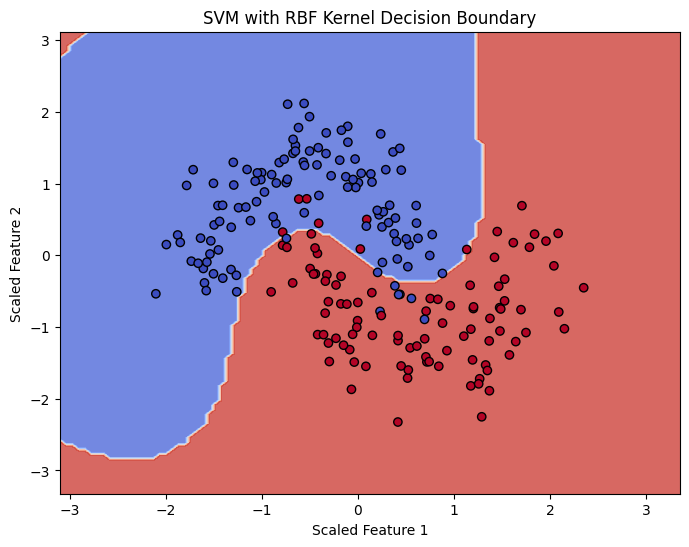

In [3]:
# Create a plotting canvas
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the decision boundary and decision regions
DecisionBoundaryDisplay.from_estimator(
    svm_model,
    X_train_scaled,
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.8,
    ax=ax,
)

# Scatter plot of the training data points
scatter = ax.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    cmap=plt.cm.coolwarm,
    edgecolors="k",
)

ax.set_title("SVM with RBF Kernel Decision Boundary")
ax.set_xlabel("Scaled Feature 1")
ax.set_ylabel("Scaled Feature 2")
plt.show()


In [4]:
from sklearn.datasets import make_circles

# Generate synthetic concentric circles data
X, y = make_circles(n_samples=300, factor=0.5, noise=0.1, random_state=42)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [5]:
# Scale features for optimal SVM performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM with RBF kernel
# The RBF kernel handles this by projecting data into a higher dimension
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Check accuracies
train_acc = svm_model.score(X_train_scaled, y_train)
test_acc = svm_model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}")


Training Accuracy: 98.57%
Testing Accuracy: 100.00%


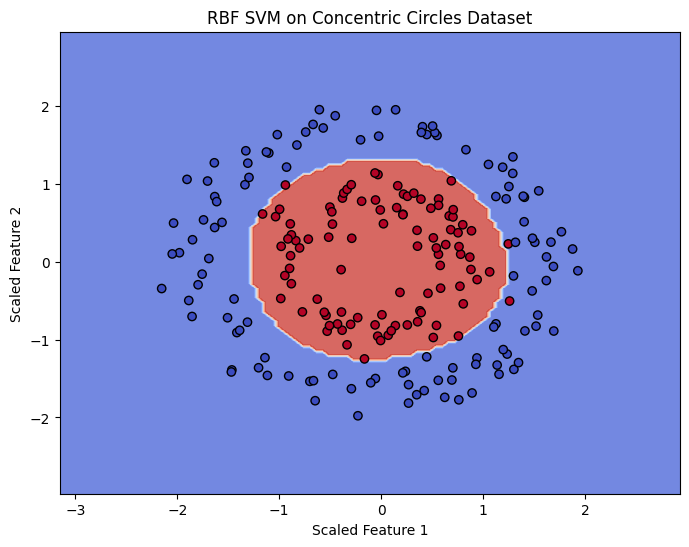

In [6]:
# Create plotting canvas
fig, ax = plt.subplots(figsize=(8, 6))

# Plot the decision boundary
DecisionBoundaryDisplay.from_estimator(
    svm_model,
    X_train_scaled,
    response_method="predict",
    cmap=plt.cm.coolwarm,
    alpha=0.8,
    ax=ax,
)

# Scatter plot of the data points
scatter = ax.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train,
    cmap=plt.cm.coolwarm,
    edgecolors="k",
)

ax.set_title("RBF SVM on Concentric Circles Dataset")
ax.set_xlabel("Scaled Feature 1")
ax.set_ylabel("Scaled Feature 2")
plt.show()
